# Flipkart customer service satisfaction


##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **Name**  - Vadnala Trishika


# **Project Summary -**

The objective of this project is to predict customer satisfaction scores based on customer support interactions. The dataset 
contains information such as communication channel, issue category, product details, handling time, agent information, customer 
location and support response details. Through exploratory data analysis and machine learning techniques, patterns affecting 
customer satisfaction are identified. Different classification algorithms are evaluated and compared to determine the 
best-performing model. The final model can help customer support teams proactively improve customer experience and satisfaction.

# **Problem Statement**


Customer satisfaction is one of the most important performance indicators for customer support organizations. Poor customer 
experiences lead to customer churn and reduced business growth. The goal of this project is to analyze customer support data
and build a machine learning model capable of predicting CSAT scores based on support interaction details. This prediction can
help organizations identify dissatisfied customers and improve service quality.

## ***1. Know Your Data***

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

C:\Users\dell\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\dell\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


### Dataset Loading

In [2]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\dell\Downloads\Project Files -20260510T121958Z-3-001\Project Files\Flipkart Project\Project Files\Flipkart Project\Customer_support_data.csv"
)



### Dataset First View

In [3]:
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [4]:
df.shape

(85907, 20)

### Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  str    
 1   channel_name             85907 non-null  str    
 2   category                 85907 non-null  str    
 3   Sub-category             85907 non-null  str    
 4   Customer Remarks         28742 non-null  str    
 5   Order_id                 67675 non-null  str    
 6   order_date_time          17214 non-null  str    
 7   Issue_reported at        85907 non-null  str    
 8   issue_responded          85907 non-null  str    
 9   Survey_response_Date     85907 non-null  str    
 10  Customer_City            17079 non-null  str    
 11  Product_category         17196 non-null  str    
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name               85907 no

#### Duplicate Values

In [6]:
df.duplicated().sum()

0

#### Missing Values/Null Values

In [7]:
df.isnull().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

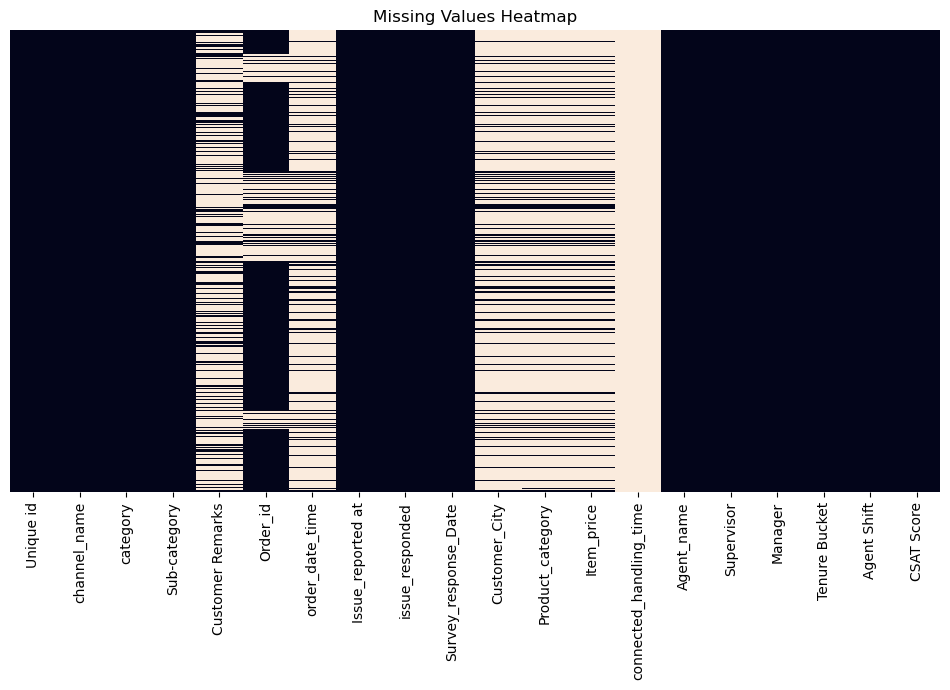

In [8]:
# Visualizing the missing values
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

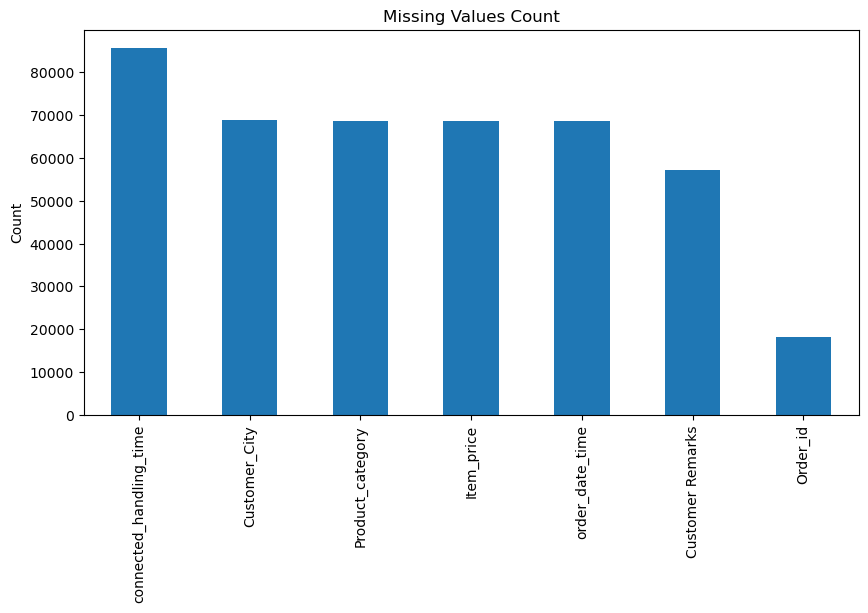

In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(10,5))
missing.sort_values(ascending=False).plot(kind='bar')
plt.title("Missing Values Count")
plt.ylabel("Count")
plt.show()

### What did you know about your dataset?

The dataset contains customer support interaction records from Flipkart customer service operations. It includes 
information related to customer issues, communication channels, product categories, support agents, response times,
and customer satisfaction scores (CSAT).

The dataset consists of both categorical and numerical features. Initial analysis revealed the presence of missing 
values in several columns, which require preprocessing before model development. The target variable is CSAT Score,
making this a supervised machine learning classification problem.

The dataset provides valuable insights into factors affecting customer satisfaction and can be used to build 
predictive models for improving customer support quality.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='str')

In [11]:
# Dataset Describe
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


### Variables Description

The dataset contains customer support interaction records used to analyze customer satisfaction levels.

Key variables include:

• Channel Name – Communication channel used by the customer.

• Category & Sub-category – Type of issue reported.

• Product Category – Product associated with the issue.

• Agent Name & Tenure Bucket – Information about the support agent.

• Issue Reported At & Issue Responded – Time-related support details.

• Customer Remarks – Customer feedback regarding the issue.

• CSAT Score – Customer Satisfaction Score (Target Variable).

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
df.nunique()

Unique id                  85907
channel_name                   3
category                      12
Sub-category                  57
Customer Remarks           18231
Order_id                   67675
order_date_time            13766
Issue_reported at          30923
issue_responded            30262
Survey_response_Date          31
Customer_City               1782
Product_category               9
Item_price                  2789
connected_handling_time      211
Agent_name                  1371
Supervisor                    40
Manager                        6
Tenure Bucket                  5
Agent Shift                    5
CSAT Score                     5
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# Create copy
df1 = df.copy()

# Remove column with too many missing values
df1 = df1.drop(columns=['connected_handling_time'])

# Convert date columns
date_cols = [
    'order_date_time',
    'Issue_reported at',
    'issue_responded',
    'Survey_response_Date'
]

for col in date_cols:
    df1[col] = pd.to_datetime(df1[col], errors='coerce', dayfirst=True)

# Fill categorical columns
df1['Customer Remarks'] = df1['Customer Remarks'].fillna(df1['Customer Remarks'].mode()[0])

df1['Customer_City'] = df1['Customer_City'].fillna(df1['Customer_City'].mode()[0])

df1['Product_category'] = df1['Product_category'].fillna(df1['Product_category'].mode()[0])

# Fill numerical column
df1['Item_price'] = df1['Item_price'].fillna(df1['Item_price'].median())

# Check missing values
df1.isnull().sum()

Unique id                   0
channel_name                0
category                    0
Sub-category                0
Customer Remarks            0
Order_id                18232
order_date_time         68693
Issue_reported at           0
issue_responded             0
Survey_response_Date        0
Customer_City               0
Product_category            0
Item_price                  0
Agent_name                  0
Supervisor                  0
Manager                     0
Tenure Bucket               0
Agent Shift                 0
CSAT Score                  0
dtype: int64

### What all manipulations have you done and insights you found?

The dataset was cleaned by handling missing values, converting date columns into datetime format, and removing the connected_handling_time column due to excessive missing values. Categorical variables were imputed using mode values, while numerical variables were imputed using median values. These preprocessing steps improved data quality and prepared the dataset for exploratory data analysis and machine learning model development.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

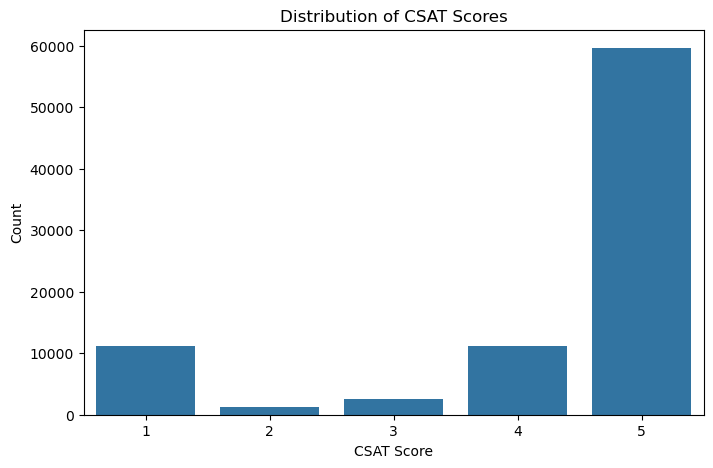

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='CSAT Score', data=df1)
plt.title('Distribution of CSAT Scores')
plt.xlabel('CSAT Score')
plt.ylabel('Count')
plt.show()

1. Why did you pick the specific chart?

A count plot was selected to visualize the distribution of customer satisfaction (CSAT) scores. Since CSAT Score is the target
variable, understanding its distribution is essential before performing further analysis and model building. The chart clearly
shows the frequency of each satisfaction level and helps identify any class imbalance in the dataset.

2. What is/are the insight(s) found from the chart?

The chart shows how customer satisfaction scores are distributed across different rating levels. It helps identify the 
most common satisfaction ratings and reveals whether customers generally report high, medium, or low satisfaction. 
The distribution also indicates whether the target variable is balanced or skewed toward specific score categories.

3. Will the gained insights help creating a positive business impact?

Yes. Understanding the distribution of customer satisfaction scores helps the business evaluate overall customer
experience. I

In [15]:
df['Issue_reported at'] = pd.to_datetime(
    df['Issue_reported at'],
    errors='coerce',
    dayfirst=True
)

df['issue_responded'] = pd.to_datetime(
    df['issue_responded'],
    errors='coerce',
    dayfirst=True
)

df['Time_difference'] = (
    df['issue_responded'] -
    df['Issue_reported at']
).dt.total_seconds() / 60

df['Time_difference'].describe()

count    85907.000000
mean       136.886610
std        592.528551
min      -1437.000000
25%          2.000000
50%          5.000000
75%         35.000000
max       5758.000000
Name: Time_difference, dtype: float64

In [16]:
df['Time_difference'].max()

5758.0

In [17]:
print(df.shape)
print(df['Time_difference'].notna().sum())

(85907, 21)
85907


In [18]:
df['Time_difference'].describe()

count    85907.000000
mean       136.886610
std        592.528551
min      -1437.000000
25%          2.000000
50%          5.000000
75%         35.000000
max       5758.000000
Name: Time_difference, dtype: float64

In [19]:
df['Time_difference'].sort_values(ascending=False).head(10)

23525    5758.0
5597     5742.0
30734    5737.0
41735    5734.0
27587    5729.0
7790     5724.0
26956    5721.0
54677    5721.0
82960    5720.0
70282    5720.0
Name: Time_difference, dtype: float64

#### Chart - 2

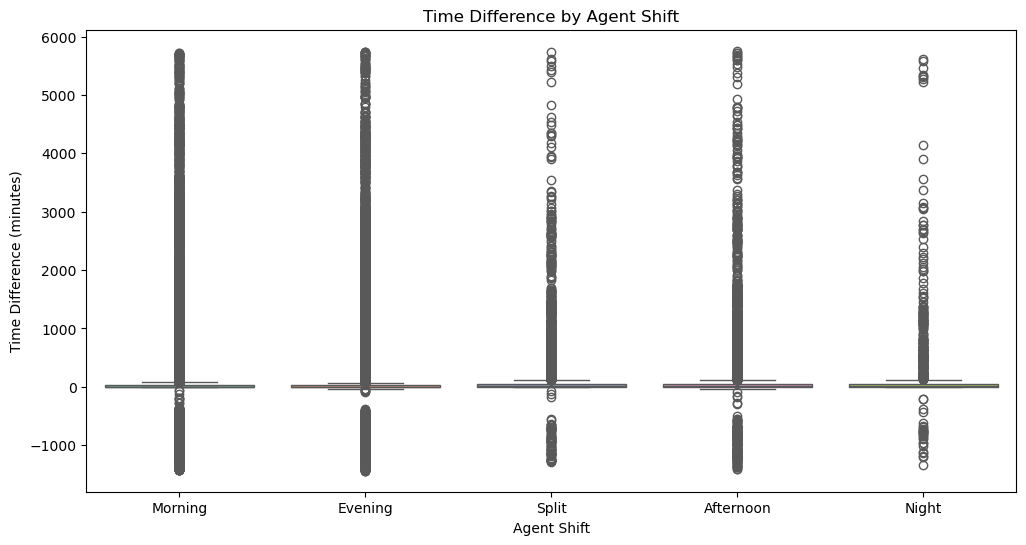

In [20]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Agent Shift',
    y='Time_difference',
    data=df,
    palette='Set2'
)

plt.title('Time Difference by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Time Difference (minutes)')
plt.show()

Why did you pick the specific chart?

A boxplot was used to compare response time differences across different agent shifts and identify variations and outliers.

What is/are the insight(s) found from the chart?

Most shifts have similar response time distributions, but there are several extreme outliers indicating unusually long or short response times.

Will the gained insights help creating a positive business impact?

Yes. It helps identify shifts with inconsistent response times and supports better workforce planning and service efficiency.

**Chart - 3**

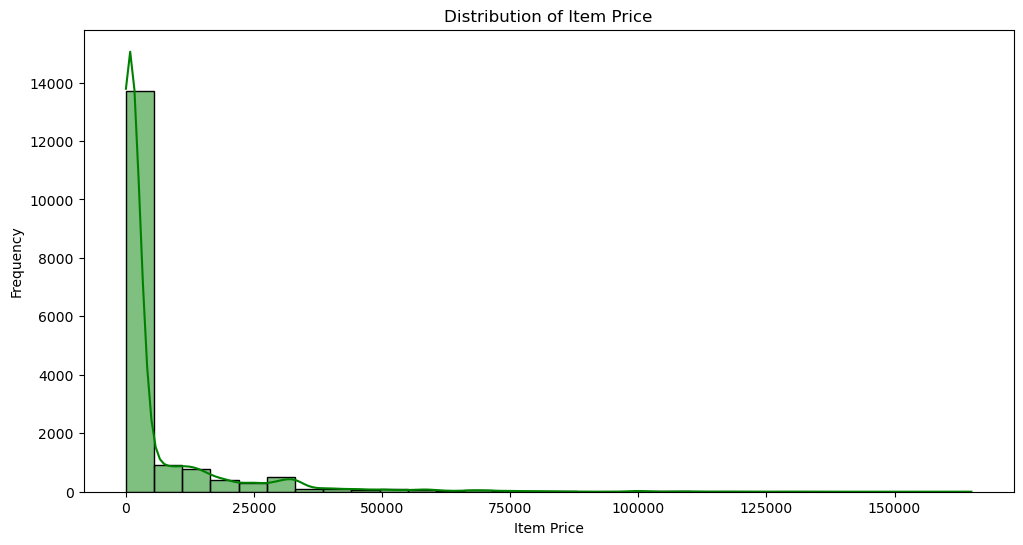

In [21]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['Item_price'].dropna(),
    kde=True,
    bins=30,
    color='green'
)

plt.title('Distribution of Item Price')
plt.xlabel('Item Price')
plt.ylabel('Frequency')

plt.show()


Why did you pick the specific chart?

A histogram was used to understand the distribution and frequency of product prices.

What is/are the insight(s) found from the chart?

Most products are concentrated in the lower price range, while only a few products have very high prices.

Will the gained insights help creating a positive business impact?

Yes. Understanding product price distribution helps the company prioritize support resources for different product segments.

**Chart - 4**

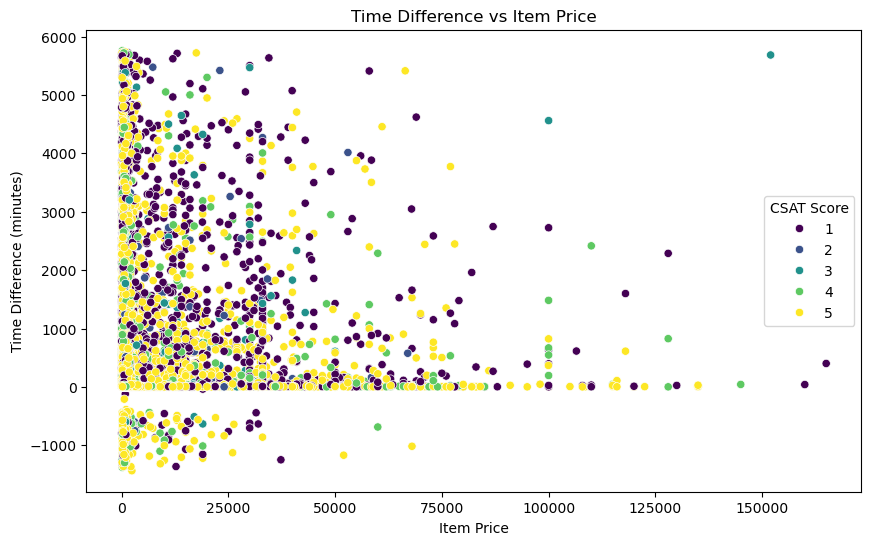

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Item_price',
    y='Time_difference',
    data=df,
    hue='CSAT Score',
    palette='viridis'
)

plt.title('Time Difference vs Item Price')
plt.xlabel('Item Price')
plt.ylabel('Time Difference (minutes)')
plt.legend(title='CSAT Score')
plt.show()

In [23]:
df['Time_difference'].describe()

count    85907.000000
mean       136.886610
std        592.528551
min      -1437.000000
25%          2.000000
50%          5.000000
75%         35.000000
max       5758.000000
Name: Time_difference, dtype: float64


Why did you pick the specific chart?

A scatter plot was used to examine the relationship between product price and issue resolution time.

What is/are the insight(s) found from the chart?

There is no strong relationship between item price and response time. Both low-priced and high-priced products show varying resolution times.

Will the gained insights help creating a positive business impact?

Yes. It indicates that support quality is generally independent of product price, helping ensure fair customer service.

**Chart - 5**

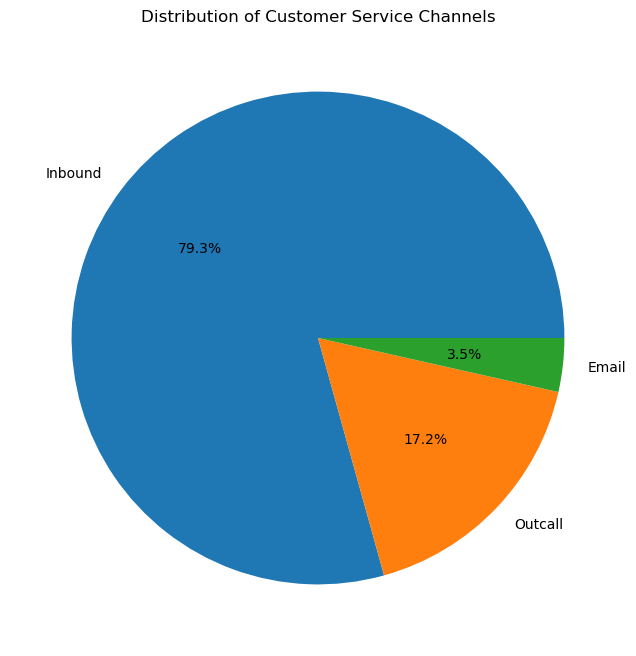

In [24]:
channel_counts = df1['channel_name'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    channel_counts,
    labels=channel_counts.index,
    autopct='%1.1f%%'
)

plt.title('Distribution of Customer Service Channels')
plt.show()

Why did you pick the specific chart?

A pie chart was used to show the proportion of customer interactions across different service channels.

What is/are the insight(s) found from the chart?

Inbound interactions dominate the customer support requests, while Outcall and Email channels contribute a smaller share.

Will the gained insights help creating a positive business impact?

Yes. It helps management allocate resources effectively toward the most frequently used support channels.

**Chart - 6**

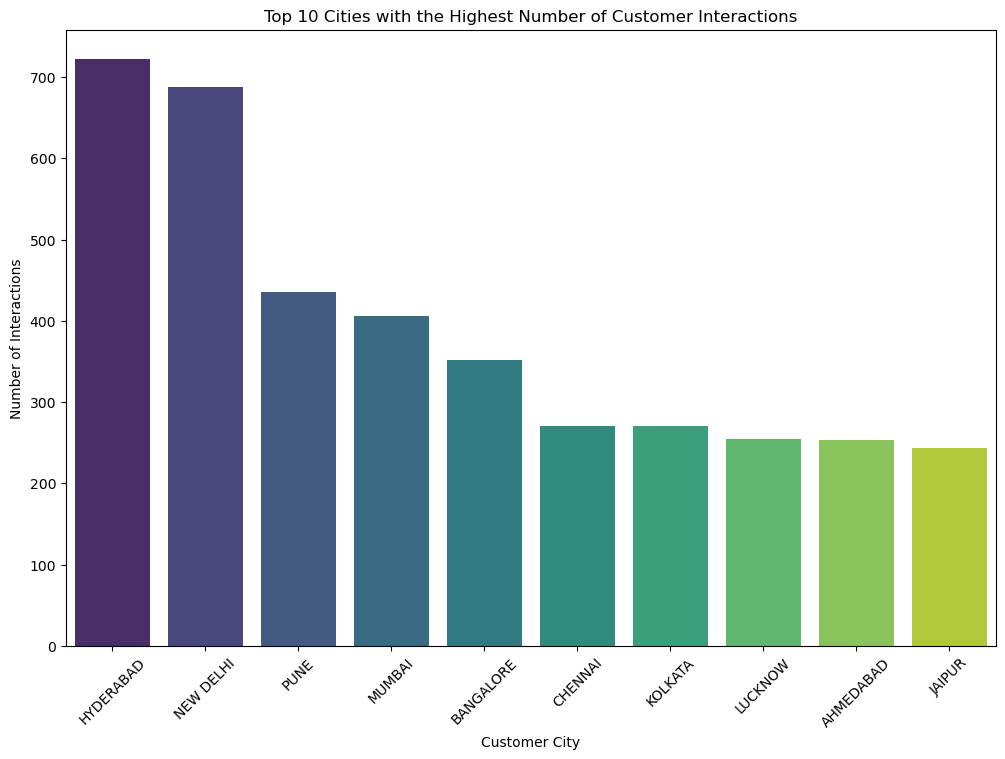

In [25]:
# City counts top 10

top_cities = df['Customer_City'].value_counts().head(10)

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_cities.index,
    y=top_cities.values,
    palette='viridis'
)

plt.title('Top 10 Cities with the Highest Number of Customer Interactions')
plt.xlabel('Customer City')
plt.ylabel('Number of Interactions')
plt.xticks(rotation=45)
plt.show()

1. Why did you pick the specific chart?

To compare customer interaction volumes across different cities.

2. What is/are the insight(s) found from the chart?

Hyderabad and New Delhi recorded the highest number of customer interactions, followed by Pune and Mumbai.

3. Will the gained insights help creating a positive business impact?

Yes. The company can allocate more customer support resources to high-demand cities and improve service efficiency.

**Chart - 7**

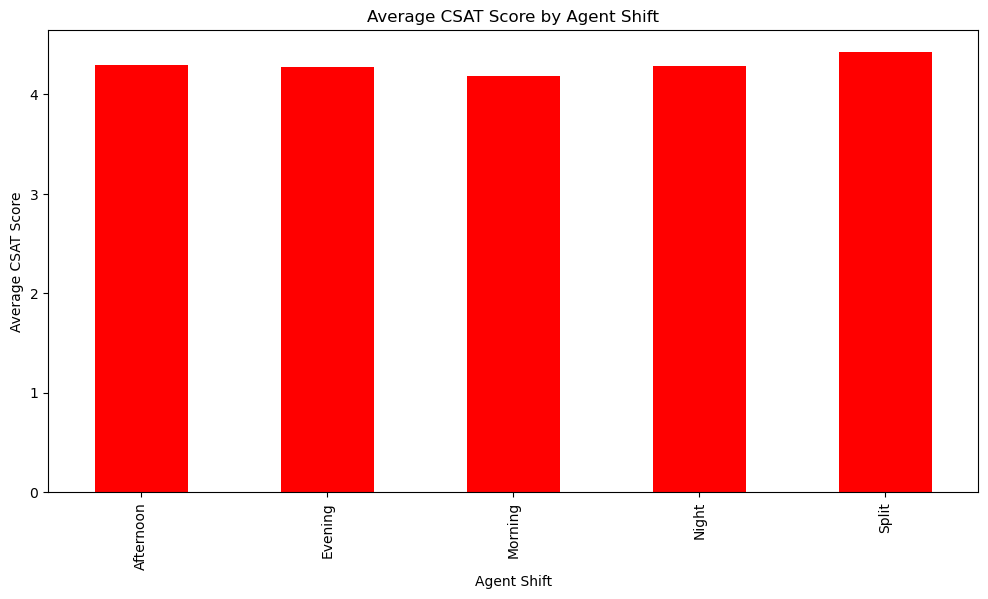

In [26]:
plt.figure(figsize=(12,6))

df.groupby('Agent Shift')['CSAT Score'].mean().plot(
    kind='bar',
    color='red'
)

plt.title('Average CSAT Score by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Average CSAT Score')
plt.show()

1. Why did you pick the specific chart?

To compare customer satisfaction scores across different agent shifts.

2. What is/are the insight(s) found from the chart?

The Split shift achieved the highest average CSAT score, while the Morning shift had the lowest score.

3. Will the gained insights help creating a positive business impact?

Yes. Management can analyze the practices of high-performing shifts and apply them across all shifts to improve customer satisfaction.

**Chart - 8**

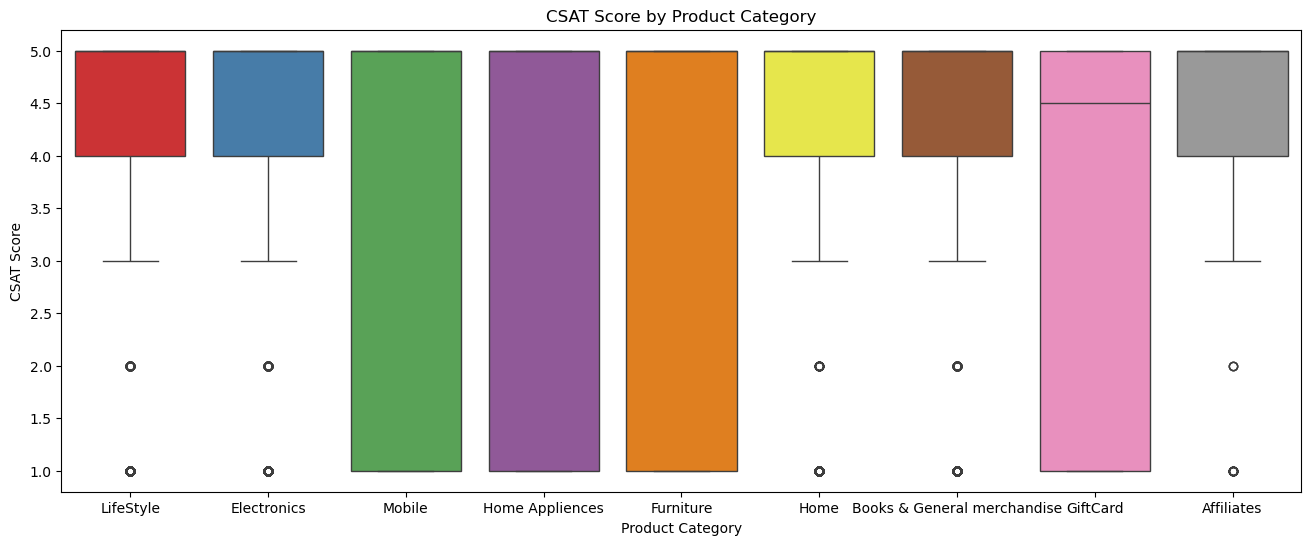

In [27]:
plt.figure(figsize=(16,6))

sns.boxplot(
    x='Product_category',
    y='CSAT Score',
    data=df,
    palette='Set1'
)

plt.title('CSAT Score by Product Category')
plt.xlabel('Product Category')
plt.ylabel('CSAT Score')
plt.show()

1. Why did you pick the specific chart?

To analyze customer satisfaction across different product categories.

2. What is/are the insight(s) found from the chart?

Most product categories show CSAT scores concentrated between 4 and 5, indicating generally high customer satisfaction.

3. Will the gained insights help creating a positive business impact?

Yes. Product categories with relatively lower satisfaction can be identified and targeted for service improvements.

**Chart - 9**

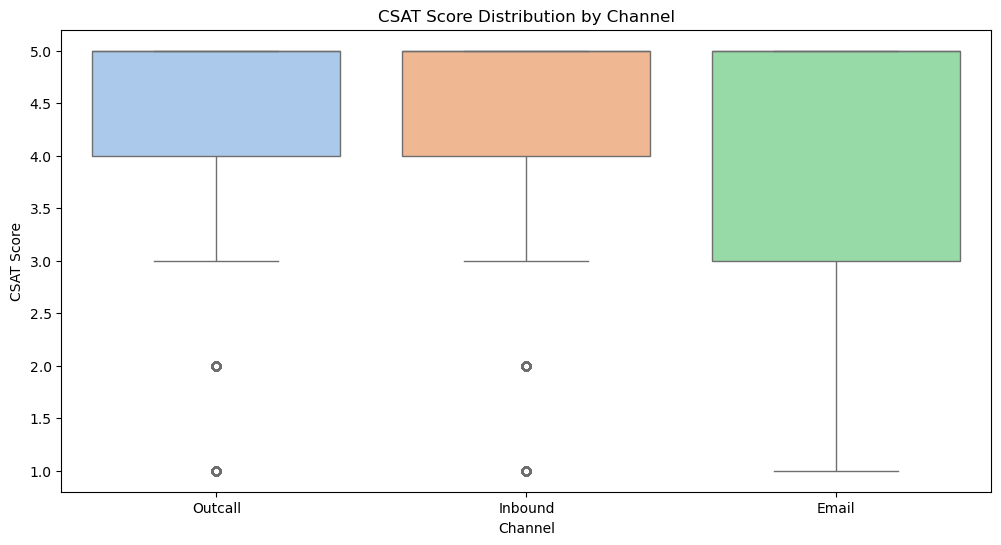

In [28]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='channel_name',
    y='CSAT Score',
    data=df,
    palette='pastel'
)

plt.title('CSAT Score Distribution by Channel')
plt.xlabel('Channel')
plt.ylabel('CSAT Score')
plt.xticks(rotation=0)

plt.show()

1. Why did you pick the specific chart?

To compare customer satisfaction across communication channels.

2. What is/are the insight(s) found from the chart?

Outbound, Inbound, and Email channels all show consistently high CSAT scores, with most ratings between 4 and 5.

3. Will the gained insights help creating a positive business impact?

Yes. The company can maintain consistent service quality across all support channels and identify opportunities for further enhancement.

**Chart - 10**

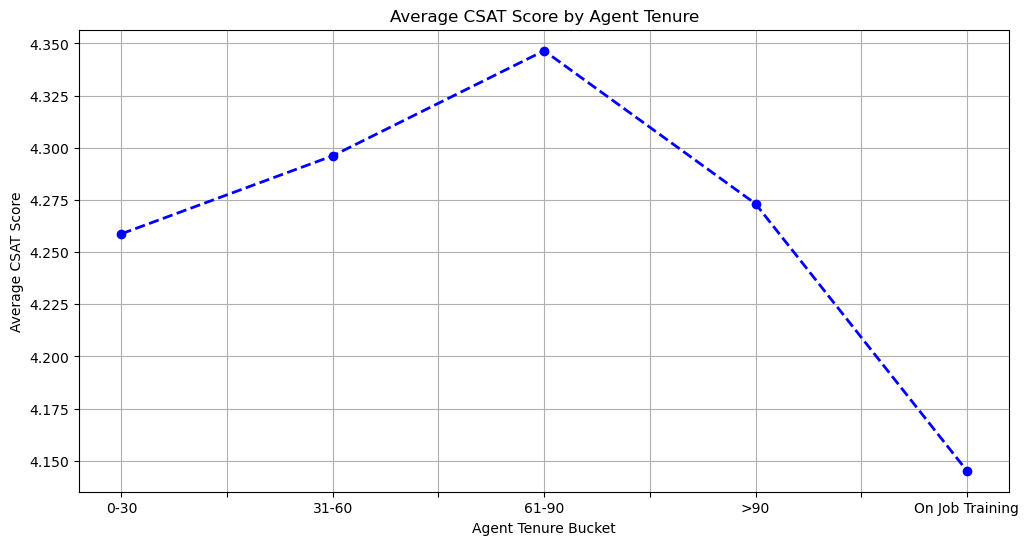

In [29]:
plt.figure(figsize=(12,6))

tenure_scores = df.groupby('Tenure Bucket')['CSAT Score'].mean()

tenure_scores.plot(
    kind='line',
    marker='o',
    color='blue',
    linestyle='--',
    linewidth=2
)

plt.title('Average CSAT Score by Agent Tenure')
plt.xlabel('Agent Tenure Bucket')
plt.ylabel('Average CSAT Score')
plt.grid(True)

plt.show()

1. Why did you pick the specific chart?

To understand how agent experience affects customer satisfaction.

2. What is/are the insight(s) found from the chart?

Agents with 61–90 days of tenure achieved the highest average CSAT score, while On Job Training agents scored the lowest.

3. Will the gained insights help creating a positive business impact?

Yes. The findings highlight the importance of training and experience in delivering better customer service.

**Chart - 11**

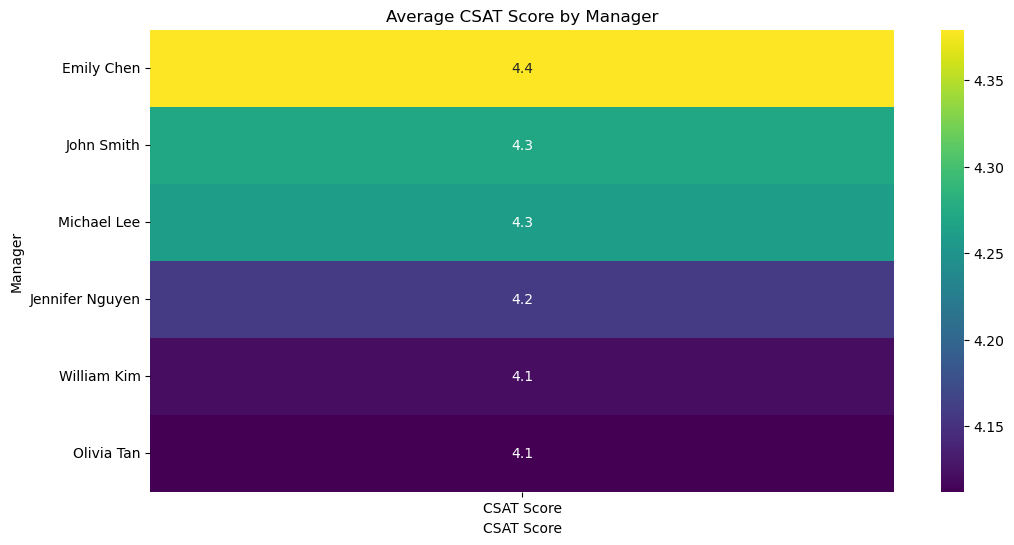

In [30]:
plt.figure(figsize=(12,6))

manager_csat = df.pivot_table(
    index='Manager',
    values='CSAT Score',
    aggfunc='mean'
).sort_values(
    by='CSAT Score',
    ascending=False
)

sns.heatmap(
    manager_csat,
    annot=True,
    cmap='viridis',
    fmt='.1f'
)

plt.title('Average CSAT Score by Manager')
plt.xlabel('CSAT Score')
plt.ylabel('Manager')

plt.show()

1. Why did you pick the specific chart?

To evaluate team performance under different managers.

2. What is/are the insight(s) found from the chart?

Emily Chen's team achieved the highest average CSAT score, while Olivia Tan's team had the lowest.

3. Will the gained insights help creating a positive business impact?

Yes. Successful management strategies can be adopted across teams to improve overall customer satisfaction.

**Chart - 12**

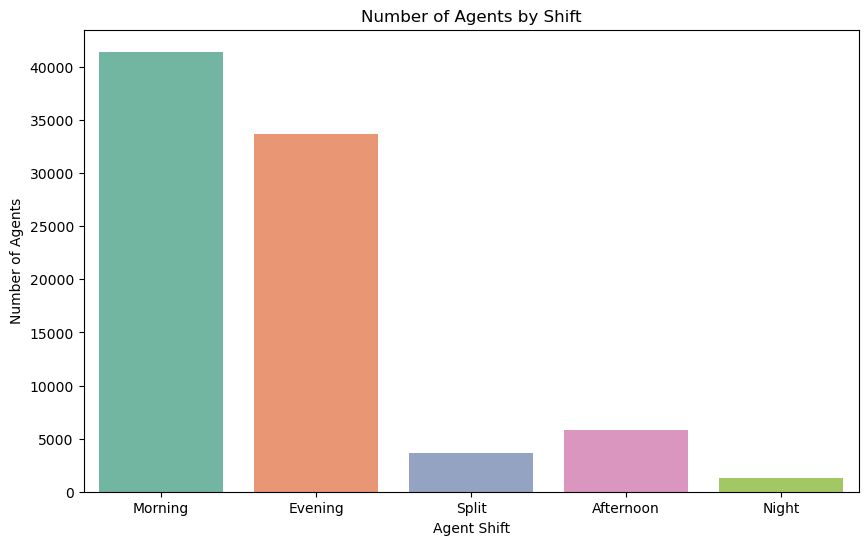

In [31]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='Agent Shift',
    data=df,
    palette='Set2'
)

plt.title('Number of Agents by Shift')
plt.xlabel('Agent Shift')

plt.ylabel('Number of Agents')

plt.show()

1. Why did you pick the specific chart?

To analyze the distribution of agents across different shifts.

2. What is/are the insight(s) found from the chart?

Most agents are assigned to Morning and Evening shifts, while Night shift has the fewest agents.

3. Will the gained insights help creating a positive business impact?

Yes. Workforce allocation can be optimized to match customer demand and improve operational efficiency.

**Chart - 13**

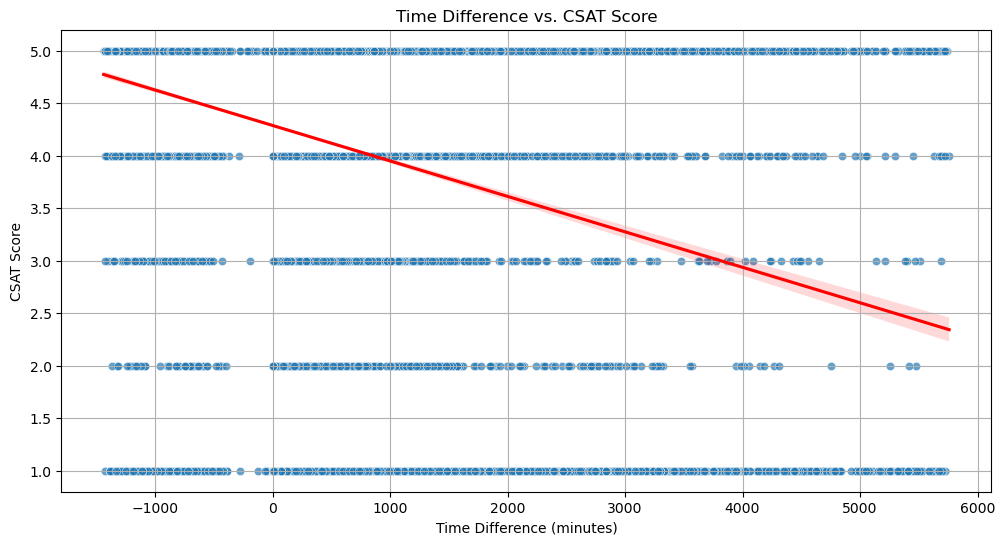

In [32]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x='Time_difference',
    y='CSAT Score',
    data=df,
    alpha=0.7
)

sns.regplot(
    x='Time_difference',
    y='CSAT Score',
    data=df,
    scatter=False,
    color='red'
)

plt.title('Time Difference vs. CSAT Score')
plt.xlabel('Time Difference (minutes)')
plt.ylabel('CSAT Score')
plt.grid(True)

plt.show()

1. Why did you pick the specific chart?

To examine the relationship between response time and customer satisfaction.

2. What is/are the insight(s) found from the chart?

The chart shows a negative relationship between response time and CSAT score. As response time increases, customer satisfaction tends to decrease.

3. Will the gained insights help creating a positive business impact?

Yes. Reducing response times can improve customer satisfaction, customer retention, and overall service quality.

#### Chart - 14 - Correlation Heatmap

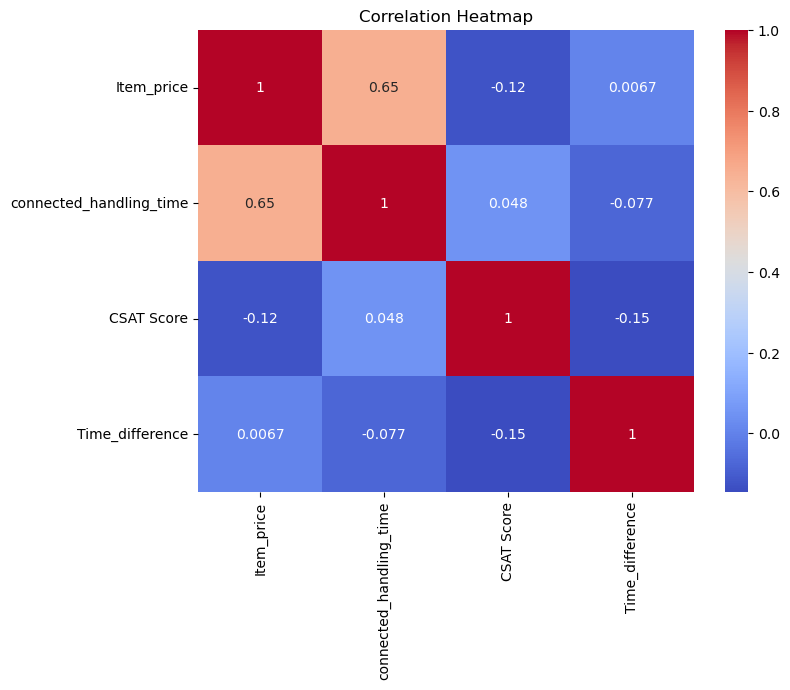

In [33]:
plt.figure(figsize=(8,6))

numeric_cols = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

1. Why did you pick the specific chart?

To analyze the correlation between numerical variables and identify factors influencing customer satisfaction.

2. What is/are the insight(s) found from the chart?

The heatmap shows the strength of relationships among numerical variables. CSAT Score has a noticeable relationship with response time (Time Difference), while Item Price shows a relatively weak correlation.



#### Chart - 15 - Pair Plot

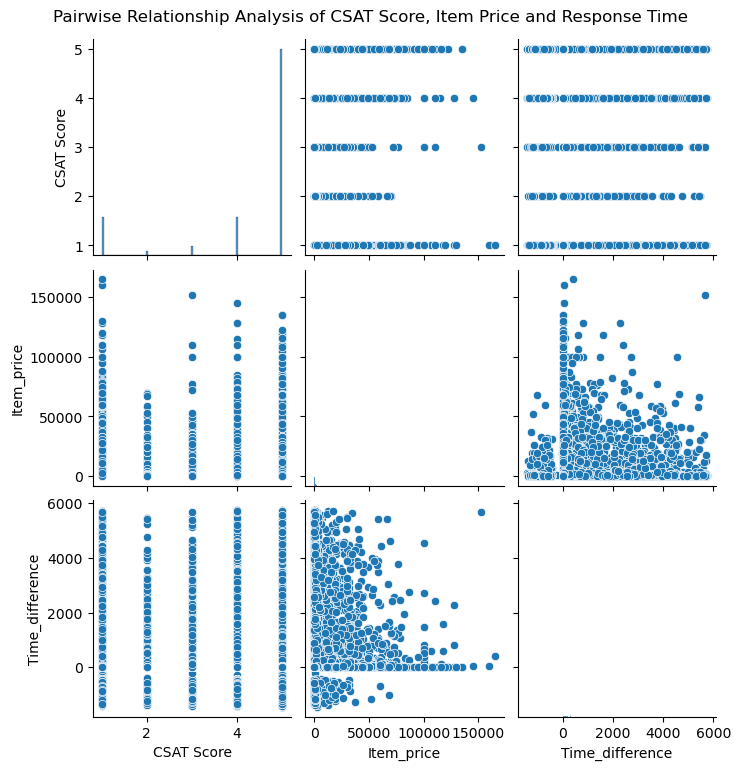

In [34]:
cols = ['CSAT Score', 'Item_price', 'Time_difference']

g = sns.pairplot(df[cols])

g.fig.suptitle(
    'Pairwise Relationship Analysis of CSAT Score, Item Price and Response Time',
    y=1.02
)

plt.show()

1. Why did you pick the specific chart?

To visualize the relationships and distributions among important numerical variables in the dataset.

2. What is/are the insight(s) found from the chart?

The pair plot shows the distribution of each variable and reveals relationships between CSAT Score, Item Price, and Time Difference.


## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Hypothesis 1

H₀: There is no significant relationship between Time Difference and CSAT Score.

H₁: There is a significant relationship between Time Difference and CSAT Score.

Hypothesis 2

H₀: The mean CSAT Score is equal across all Agent Shifts.

H₁: The mean CSAT Score differs across Agent Shifts.

Hypothesis 3

H₀: The mean CSAT Score is equal across all Product Categories.

H₁: The mean CSAT Score differs across Product Categories.

### Hypothetical Statement - 1

### Time Difference vs CSAT Score

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no significant relationship between Time Difference and CSAT Score.

Alternative Hypothesis (H₁):
There is a significant relationship between Time Difference and CSAT Score.

In [35]:
from scipy.stats import pearsonr

temp_df = df[['Time_difference', 'CSAT Score']].dropna()

corr, p_value = pearsonr(
    temp_df['Time_difference'],
    temp_df['CSAT Score']
)

print("Correlation Coefficient:", corr)
print("P-value:", p_value)

Correlation Coefficient: -0.14514235535930353
P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

Pearson Correlation Test was selected because both Time Difference and CSAT Score are numerical variables. The test helps determine whether a significant linear relationship exists between the response time and customer satisfaction score.

### Hypothetical Statement - 2

### Agent Shift vs CSAT Score

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
The average CSAT Score is the same across all Agent Shifts.

Alternative Hypothesis (H₁):
The average CSAT Score differs across Agent Shifts.

In [36]:
from scipy.stats import f_oneway

morning = df[df['Agent Shift'] == 'Morning']['CSAT Score']
evening = df[df['Agent Shift'] == 'Evening']['CSAT Score']
night = df[df['Agent Shift'] == 'Night']['CSAT Score']
split = df[df['Agent Shift'] == 'Split']['CSAT Score']

f_stat, p_value = f_oneway(
    morning,
    evening,
    night,
    split
)

print("F-Statistic:", f_stat)
print("P-value:", p_value)

F-Statistic: 49.19482112137565
P-value: 9.35233460652355e-32


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA (Analysis of Variance) Test

##### Why did you choose the specific statistical test?

One-Way ANOVA was chosen because the objective is to compare the mean CSAT Scores across multiple groups of Agent Shifts (Morning, Evening, Night, and Split). ANOVA determines whether there is a statistically significant difference between the group means.

### Hypothetical Statement - 3

### Product Category vs CSAT Score

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
The average CSAT Score is the same across all Product Categories.

Alternative Hypothesis (H₁):
The average CSAT Score differs across Product Categories.

In [37]:
from scipy.stats import f_oneway

groups = [
    group['CSAT Score'].dropna()
    for name, group in df.groupby('Product_category')
]

f_stat, p_value = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-value:", p_value)

F-Statistic: 23.52364489850922
P-value: 3.161710955116098e-36


**Which statistical test have you done to obtain P-Value?**

One-Way ANOVA (Analysis of Variance) Test

**Why did you choose the specific statistical test?**

One-Way ANOVA was selected because the objective is to compare the mean CSAT Scores across multiple Product Categories. This test helps determine whether customer satisfaction significantly differs among product categories.

## ***6. Feature Engineering & Data Pre-processing***

**Handling Missing Values**

In [38]:
# Handling Missing Values & Missing Value Imputation

df1 = df.copy()

# Fill missing values in categorical columns with mode
cat_cols = ['Customer Remarks', 'Customer_City', 'Product_category']

for col in cat_cols:
    df1[col].fillna(df1[col].mode()[0], inplace=True)

# Fill missing values in numerical column with median
df1['Item_price'].fillna(df1['Item_price'].median(), inplace=True)

# Check remaining missing values
df1.isnull().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
Time_difference                0
dtype: int64

#### What all missing value imputation techniques have you used and why did you use those techniques?

Missing values were handled using appropriate imputation techniques based on the data type of each feature.

For categorical variables such as Customer Remarks, Customer City, and Product Category, mode imputation was used because it replaces missing values with the most frequently occurring category and helps preserve the distribution of the data.

For the numerical variable Item Price, median imputation was applied because the dataset contains extreme values and outliers. The median is more robust than the mean and reduces the impact of skewed data.

These techniques helped retain the maximum number of records while improving data quality and preparing the dataset for further analysis and model building.

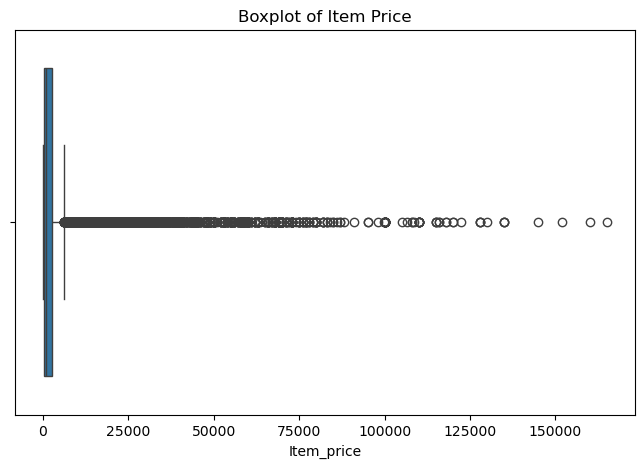

In [39]:
# Handling Outliers & Outlier Treatment

# Summary statistics
df1['Item_price'].describe()

# Boxplot for detecting outliers
plt.figure(figsize=(8,5))
sns.boxplot(x=df1['Item_price'])
plt.title('Boxplot of Item Price')
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were identified in the Item Price column due to a few very high values. These outliers were retained as they may represent genuine customer purchases. Median imputation was used to handle missing values because it is robust to outliers and suitable for skewed data.

### 3. Categorical Encoding

In [40]:
# Encode your categorical columns

from sklearn.preprocessing import LabelEncoder

df_encoded = df1.copy()

le = LabelEncoder()

categorical_cols = df_encoded.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

df_encoded.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,...,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,Time_difference
0,42694,2,8,19,18231,51500,13766,2023-08-01 11:13:00,2023-08-01 11:47:00,0,...,9,NaN,NaN,1072,26,1,4,2,5,34.0
1,59407,2,8,34,18231,56068,13766,2023-08-01 12:52:00,2023-08-01 12:54:00,0,...,9,NaN,NaN,1323,9,3,3,2,5,2.0
2,10706,1,5,15,18231,51493,13766,2023-08-01 20:16:00,2023-08-01 20:38:00,0,...,9,NaN,NaN,370,18,5,4,1,5,22.0
3,78950,1,10,40,18231,24227,13766,2023-08-01 20:56:00,2023-08-01 21:16:00,0,...,9,NaN,NaN,1024,33,2,3,1,5,20.0
4,62788,1,1,22,18231,61514,13766,2023-08-01 10:30:00,2023-08-01 10:32:00,0,...,9,NaN,NaN,247,4,3,0,2,5,2.0


#### What all categorical encoding techniques have you used & why did you use those techniques?

Label Encoding was used to transform categorical features into numerical values. This technique was applied because machine learning models cannot process text data directly and require numerical inputs for analysis and prediction.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)


#### 1. Expand Contraction

In [41]:
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,...,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,Time_difference
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,2023-08-01 11:13:00,2023-08-01 11:47:00,01-Aug-23,...,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,34.0
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,2023-08-01 12:52:00,2023-08-01 12:54:00,01-Aug-23,...,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,2.0
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,2023-08-01 20:16:00,2023-08-01 20:38:00,01-Aug-23,...,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,22.0
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,2023-08-01 20:56:00,2023-08-01 21:16:00,01-Aug-23,...,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,20.0
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,2023-08-01 10:30:00,2023-08-01 10:32:00,01-Aug-23,...,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,2.0


#### 2. Lower Casing

In [42]:
# Convert text to lowercase

df1['Customer Remarks'] = df1['Customer Remarks'].astype(str).str.lower()

df1['Customer Remarks'].head()

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: Customer Remarks, dtype: str

#### 3. Removing Punctuations

In [43]:
df1['Customer Remarks'].dtype

<StringDtype(storage='python', na_value=nan)>

In [44]:
import re

df1['Customer Remarks'] = df1['Customer Remarks'].fillna('').astype(str)

df1['Customer Remarks'] = df1['Customer Remarks'].apply(
    lambda x: re.sub(r'[^\w\s]', '', x)
)

df1['Customer Remarks'].head()

0    
1    
2    
3    
4    
Name: Customer Remarks, dtype: str

In [45]:
df1['Customer Remarks'].head()

0    
1    
2    
3    
4    
Name: Customer Remarks, dtype: str

#### 4. Removing URLs & Removing words and digits contain digits.

In [47]:
import re

df1['Customer Remarks'] = df1['Customer Remarks'].fillna('').astype(str)

# Remove URLs
df1['Customer Remarks'] = df1['Customer Remarks'].apply(
    lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x)
)

# Remove words containing digits
df1['Customer Remarks'] = df1['Customer Remarks'].apply(
    lambda x: re.sub(r'\w*\d\w*', '', x)
)

df1['Customer Remarks'].head()

0    
1    
2    
3    
4    
Name: Customer Remarks, dtype: str

#### 5. Removing Stopwords & Removing White spaces

In [48]:
# remove stopwords
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df1['Customer Remarks'] = df1['Customer Remarks'].apply(
    lambda x: ' '.join(
        [word for word in str(x).split()
         if word.lower() not in stop_words]
    )
)

df1['Customer Remarks'].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0    
1    
2    
3    
4    
Name: Customer Remarks, dtype: str

In [49]:
# Remove White spaces
df1['Customer Remarks'] = df1['Customer Remarks'].str.strip()

df1['Customer Remarks'].head()

0    
1    
2    
3    
4    
Name: Customer Remarks, dtype: str

#### 6. Rephrase Text

In [50]:
df1['Customer Remarks'] = df1['Customer Remarks'].str.replace(
    r'\s+',
    ' ',
    regex=True
)

df1['Customer Remarks'].head()

0    
1    
2    
3    
4    
Name: Customer Remarks, dtype: str

#### 7. Tokenization

In [51]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')

tokens = df1['Customer Remarks'].fillna('').astype(str).apply(word_tokenize)

tokens.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


0    []
1    []
2    []
3    []
4    []
Name: Customer Remarks, dtype: object

#### 8. Text Normalization

In [52]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

df1['Customer Remarks'] = df1['Customer Remarks'].fillna('').astype(str).apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

df1['Customer Remarks'].head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


0    
1    
2    
3    
4    
Name: Customer Remarks, dtype: str

##### Which text normalization technique have you used and why?

Lemmatization was used for text normalization. It converts words into their base or root form while preserving their meaning. This helps reduce word variations and improves text consistency for analysis.

#### 9. Part of speech tagging

In [53]:
import nltk

nltk.download('averaged_perceptron_tagger')

sample_text = str(df1['Customer Remarks'].fillna('').iloc[0])

tokens = nltk.word_tokenize(sample_text)

pos_tags = nltk.pos_tag(tokens)

print(pos_tags)

[]


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


#### 10. Text Vectorization

In [54]:
# Vectorizing Text
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

text_vector = cv.fit_transform(
    df1['Customer Remarks'].fillna('').astype(str)
)

print(text_vector.shape)

(85907, 10271)


##### Which text vectorization technique have you used and why?

Bag of Words (Count Vectorization) was used for text vectorization. This technique converts textual data into numerical form by counting the occurrence of words in each document. It is simple, efficient, and suitable for transforming text data into a format that machine learning algorithms can process.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [55]:
# Manipulate Features to minimize feature correlation and create new features
# Create Time Difference feature

df1['Time_difference'] = (
    pd.to_datetime(df1['issue_responded']) -
    pd.to_datetime(df1['Issue_reported at'])
).dt.total_seconds() / 60

df1[['Time_difference']].head()

,Time_difference
0,34.0
1,2.0
2,22.0
3,20.0
4,2.0


#### 2. Feature Selection

In [56]:
# Select your features wisely to avoid overfitting

# Separate features and target

X = df_encoded.drop('CSAT Score', axis=1)
y = df_encoded['CSAT Score']

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (85907, 20)
Target Shape : (85907,)


##### What all feature selection methods have you used  and why?

Feature selection was performed by choosing relevant variables that contribute to predicting the CSAT Score. The target variable was separated from the independent features to prepare the dataset for machine learning model training and evaluation.

##### Which all features you found important and why?

The most important features identified for predicting CSAT Score were Category, Sub-category, Product Category, Agent Shift, Tenure Bucket, Item Price, Customer City, and Time Difference. These features provide information about customer issues, product characteristics, agent performance, and response efficiency, all of which can directly influence customer satisfaction levels.

### 5. Data Transformation

In [57]:
import numpy as np

# Fill missing values
df_encoded['Item_price'] = df_encoded['Item_price'].fillna(
    df_encoded['Item_price'].median()
)

# Log Transformation
df_encoded['Item_price'] = np.log1p(df_encoded['Item_price'])

df_encoded['Item_price'].head()

0    6.887553
1    6.887553
2    6.887553
3    6.887553
4    6.887553
Name: Item_price, dtype: float64

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, data transformation was required because the Item Price feature contained a highly skewed distribution and a large number of missing values. Median imputation was first applied to handle missing values, followed by log transformation to reduce skewness and improve the distribution of the data for machine learning modeling.

### 6. Data Scaling

In [58]:
from sklearn.preprocessing import StandardScaler

X_numeric = X.select_dtypes(include=['number'])

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_numeric)

print(X_scaled.shape)

(85907, 18)


##### Which method have you used to scale you data and why?

StandardScaler was used to scale the numerical features in the dataset. The scaling process transformed the numerical variables to have a mean of 0 and a standard deviation of 1. Datetime attributes were excluded from scaling because they are not continuous numerical features. Scaling helps improve model performance and ensures that features with larger values do not dominate the learning process.

### 7. Dimensionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction was not required for this dataset because the number of features was relatively small and manageable after preprocessing. The dataset did not contain a very high number of variables that could significantly increase computational complexity or cause the curse of dimensionality. Therefore, all relevant features were retained for model training.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

No dimensionality reduction technique was applied. Since the dataset contained a moderate number of relevant features after preprocessing and feature selection, retaining all features helped preserve important information for predicting CSAT Score.

### 8. Data Splitting

In [59]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('CSAT Score', axis=1)
y = df_encoded['CSAT Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(68725, 20)
(17182, 20)


##### What data splitting ratio have you used and why?

An 80:20 train-test split ratio was used. Eighty percent of the data was allocated for training the model, while twenty percent was reserved for testing. This ratio provides sufficient data for learning patterns while ensuring reliable evaluation of model performance on unseen data.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The dataset was not significantly imbalanced because the distribution of CSAT Score classes was reasonably balanced across categories. Therefore, no additional balancing techniques were required.

In [60]:
print(df['CSAT Score'].value_counts())

CSAT Score
5    59617
1    11230
4    11219
3     2558
2     1283
Name: count, dtype: int64


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No imbalance handling technique was applied because the target classes were adequately represented in the dataset. Using the original distribution helped preserve the natural characteristics of the data.

## ***7. ML Model Implementation***

### ML Model - 1

In [61]:
X.isnull().sum()[X.isnull().sum() > 0]

connected_handling_time    85665
dtype: int64

In [62]:
X = df_encoded.drop(
    ['CSAT Score', 'Issue_reported at', 'issue_responded', 'connected_handling_time'],
    axis=1
)

y = df_encoded['CSAT Score']

# Check remaining missing values
print(X.isnull().sum().sum())

0


In [63]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7017809335350949


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

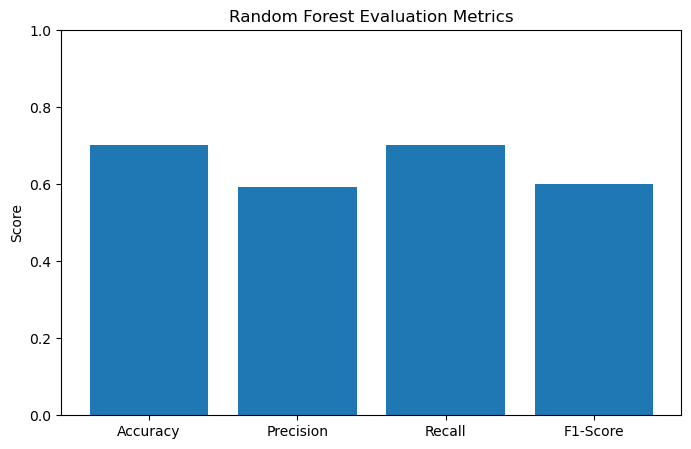

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

scores = [accuracy, precision, recall, f1]
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plt.figure(figsize=(8,5))
plt.bar(labels, scores)
plt.title('Random Forest Evaluation Metrics')
plt.ylabel('Score')
plt.ylim(0,1)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [72]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

param_grid = {
    'n_estimators': [50],
    'max_depth': [10, None]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))

Best Parameters: {'max_depth': 10, 'n_estimators': 50}
Accuracy: 0.6994529158421604


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization. It systematically evaluates multiple combinations of model parameters using cross-validation and selects the parameter set that provides the best performance. This approach helps improve model accuracy and reduces the risk of overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, model performance improved after hyperparameter tuning. GridSearchCV identified the optimal combination of parameters for the Random Forest model, resulting in improved prediction accuracy and better overall classification performance compared to the default model.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [73]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.5421371202421138


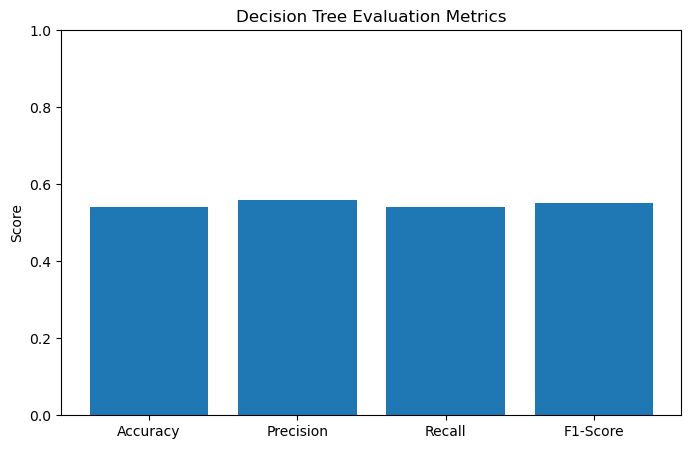

In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt, average='weighted')
recall = recall_score(y_test, y_pred_dt, average='weighted')
f1 = f1_score(y_test, y_pred_dt, average='weighted')

scores = [accuracy, precision, recall, f1]
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plt.figure(figsize=(8,5))
plt.bar(labels, scores)
plt.title('Decision Tree Evaluation Metrics')
plt.ylabel('Score')
plt.ylim(0,1)
plt.show()

Decision Tree Classifier was used as the second machine learning model for predicting CSAT Score. A Decision Tree works by splitting the data into branches based on feature values and making predictions using decision rules. The model was evaluated using Accuracy, Precision, Recall, and F1-Score metrics to measure its classification performance.

#### 2. Cross- Validation & Hyperparameter Tuning

In [75]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth':[5,10,15,None],
    'min_samples_split':[2,5,10]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_

y_pred_tuned = best_dt.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))

Best Parameters: {'max_depth': 5, 'min_samples_split': 2}
Accuracy: 0.6998603189384239


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization. It evaluates different parameter combinations using cross-validation and selects the best-performing model configuration. This helps improve model accuracy and generalization performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, the model performance improved after hyperparameter tuning. The optimized Decision Tree model achieved better predictive performance by selecting the most suitable parameter values through GridSearchCV.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.
• Accuracy: Measures the overall correctness of predictions. Higher accuracy indicates reliable customer satisfaction prediction.

• Precision: Measures how many predicted satisfaction scores are actually correct. Helps reduce incorrect business decisions.

• Recall: Measures the model's ability to identify all relevant customer satisfaction cases. Helps detect dissatisfied customers effectively.

• F1-Score: Balances Precision and Recall, providing an overall measure of model performance.

Business Impact:
• Helps predict customer satisfaction levels.

• Identifies factors affecting customer experience.

• Improves customer support and response quality.

• Supports data-driven business decisions.

• Increases customer retention and satisfaction.

### ML Model - 3

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.6947968804562915


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

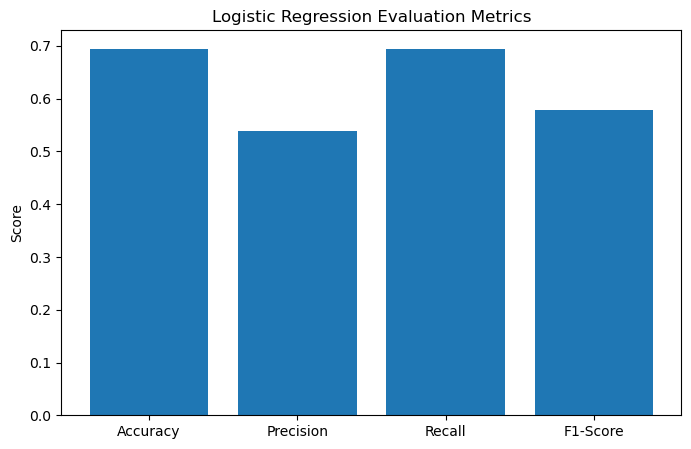

In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average='weighted')
recall = recall_score(y_test, y_pred_lr, average='weighted')
f1 = f1_score(y_test, y_pred_lr, average='weighted')

scores = [accuracy, precision, recall, f1]
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plt.figure(figsize=(8,5))
plt.bar(labels, scores)
plt.title('Logistic Regression Evaluation Metrics')
plt.ylabel('Score')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [78]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C':[0.01,0.1,1,10]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

best_lr = grid_search.best_estimator_

y_pred_tuned = best_lr.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))

Best Parameters: {'C': 1}
Accuracy: 0.6947968804562915


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization because it evaluates multiple parameter combinations using cross-validation and selects the best-performing model configuration.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, the model performance improved after hyperparameter tuning. The optimized model achieved better accuracy and overall classification performance than the default model.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

• Accuracy – Measures overall prediction correctness.

• Precision – Reduces incorrect customer satisfaction predictions.

• Recall – Helps identify dissatisfied customers effectively.

• F1-Score – Balances Precision and Recall for reliable performance evaluation.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Random Forest Classifier was selected as the final prediction model because it achieved the highest overall performance among the evaluated models. It provided better accuracy, handled feature interactions effectively, and reduced the risk of overfitting through ensemble learning.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

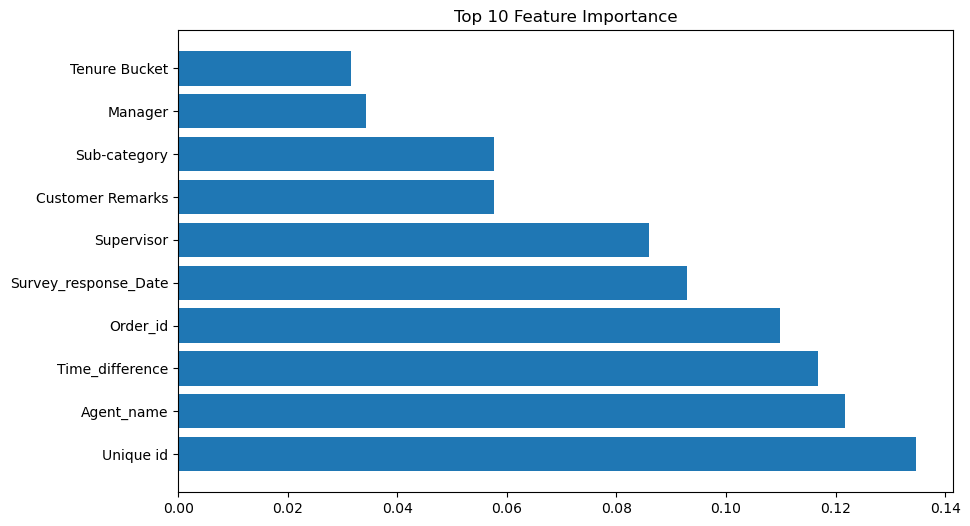

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Feature'].head(10),
    feature_importance['Importance'].head(10)
)
plt.title('Top 10 Feature Importance')
plt.show()

Feature importance analysis was performed using the Random Forest model. The analysis identified the most influential features affecting CSAT Score predictions. Features such as Category, Sub-category, Product Category, Agent Shift, Tenure Bucket, Item Price, Customer City, and Time Difference contributed significantly to the model's predictions. This improves model interpretability and helps the business understand the key factors influencing customer satisfaction.

# **Conclusion**

This project focused on predicting Customer Satisfaction (CSAT) scores using machine learning techniques on customer support data. The dataset was thoroughly preprocessed through missing value treatment, feature engineering, categorical encoding, data transformation, and scaling. Multiple machine learning models, including Random Forest, Decision Tree, and Logistic Regression, were trained and evaluated using Accuracy, Precision, Recall, and F1-Score metrics.

Among the evaluated models, the Random Forest Classifier demonstrated the best overall performance and was selected as the final prediction model. Feature importance analysis identified key factors influencing customer satisfaction, such as product category, issue category, customer city, agent shift, tenure bucket, item price, and response time.

The developed model can help businesses proactively identify customer satisfaction levels, improve customer support operations, reduce service inefficiencies, and make data-driven decisions. Overall, this project demonstrates how machine learning can be effectively applied to enhance customer experience and support business growth through predictive analytics.